# Sensitivity analysis

Which parameters drive each RAW case's net impact? The parameters on the sheet are grouped into four types:

- **design** choices: product size formula constants (density, ratios), bill of materials (recycled/co-product share),
- **manufacturing** choices: machine weight, power, output rate, machine lifetime, process yield, machine source,
- **circularity** choices: lifetime, repair, end-of-life shares,
- **location** choices: electricity country of each step and of the end-of-life grid (varies between `location_choices` on the sheet).

Method: variance-based total-order Sobol' indices (Jansen estimator, `raw_lca/sensitivity.py`) with bootstrap 95 % confidence intervals, per group and per parameter, for the net impact in each charted category; parameter ranges are the min/max on the sheet. The one-at-a-time tornado shows the swing of the net climate change between min and max of each parameter. Background (ecoinvent) uncertainty is not part of this analysis. Sample size N: `sobol_base_samples` on the sheet.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # repo root, so that `raw_lca` can be imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from raw_lca import Background, Model, load_inputs, run_products, spec_variable
from raw_lca.paths import BACKGROUND, RESULTS, newest_snapshot
from raw_lca.plots import plot_today_vs_2050

SNAPSHOT = newest_snapshot()
inp = load_inputs(SNAPSHOT)                          # validates the sheet snapshot, stops on errors
print("sheet snapshot:", SNAPSHOT.name)

# the two backgrounds shown in the charts: the scenarios flagged in_results on the sheet (first = today)
scn = inp.scenarios[inp.scenarios["in_results"].astype(str).str.upper() == "TRUE"]
(id_a, label_a), (id_b, label_b) = list(zip(scn["scenario_id"], scn["label"]))[:2]
models = {id_a: Model(inp, Background(BACKGROUND, id_a)), id_b: Model(inp, Background(BACKGROUND, id_b))}
(RESULTS / "figures").mkdir(parents=True, exist_ok=True); (RESULTS / "tables").mkdir(parents=True, exist_ok=True)

from raw_lca.sensitivity import sobol, tornado
from raw_lca.plots import plot_group_sensitivity, plot_parameter_sensitivity, plot_tornado, plot_top_group_tables, chart_categories
N, seed = int(inp.setup["sobol_base_samples"]), int(inp.setup["mc_seed"])

sheet snapshot: 2026-09-25


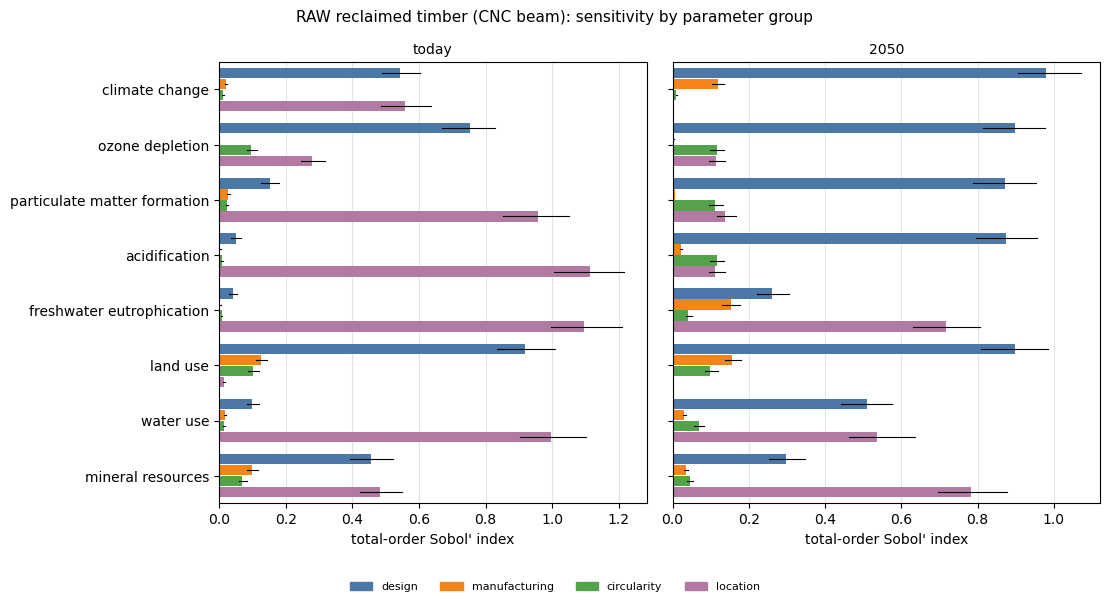

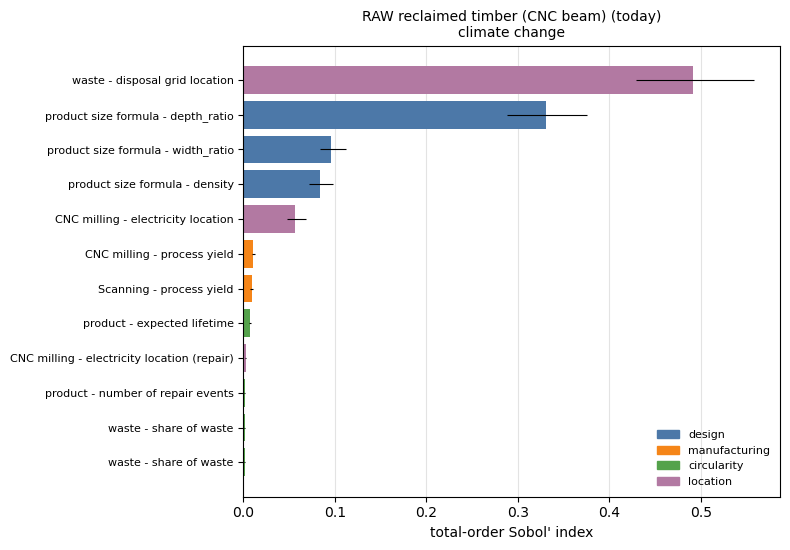

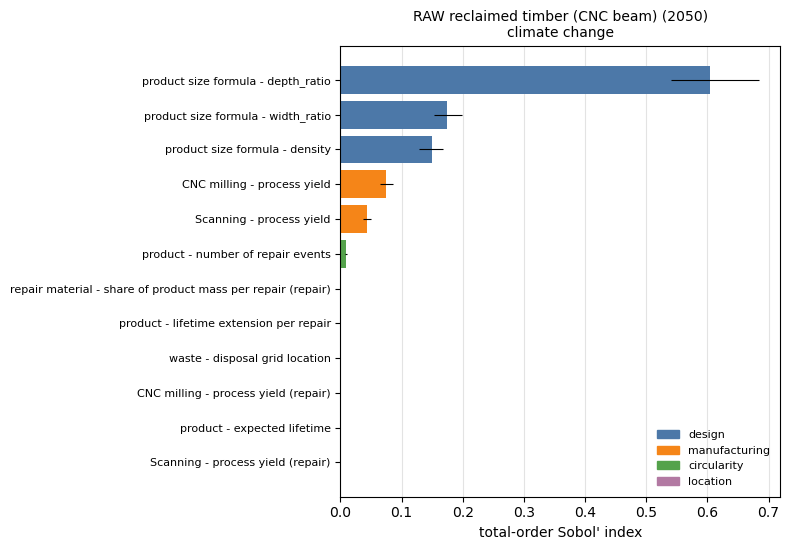

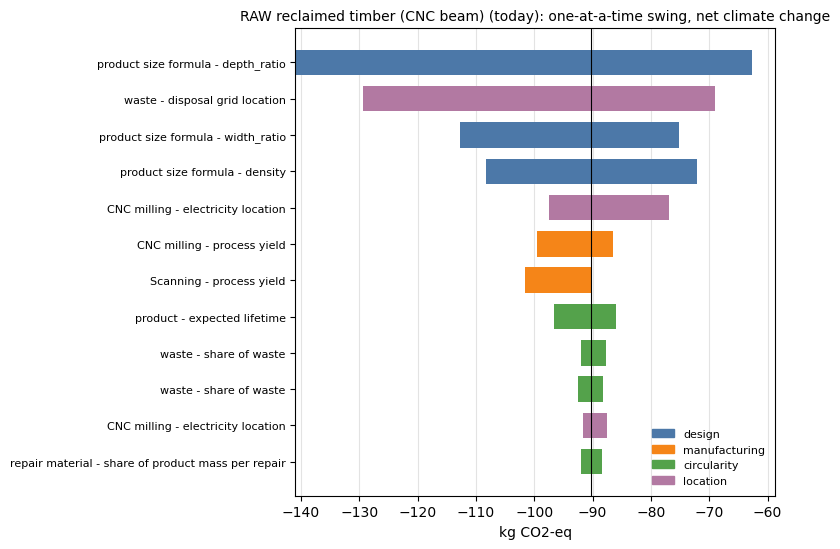

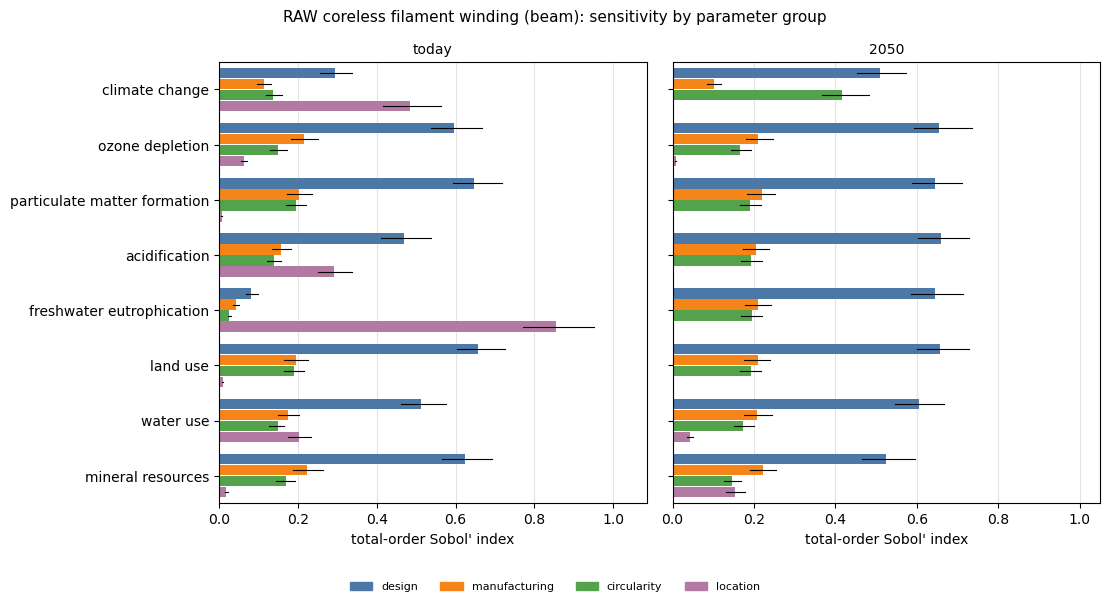

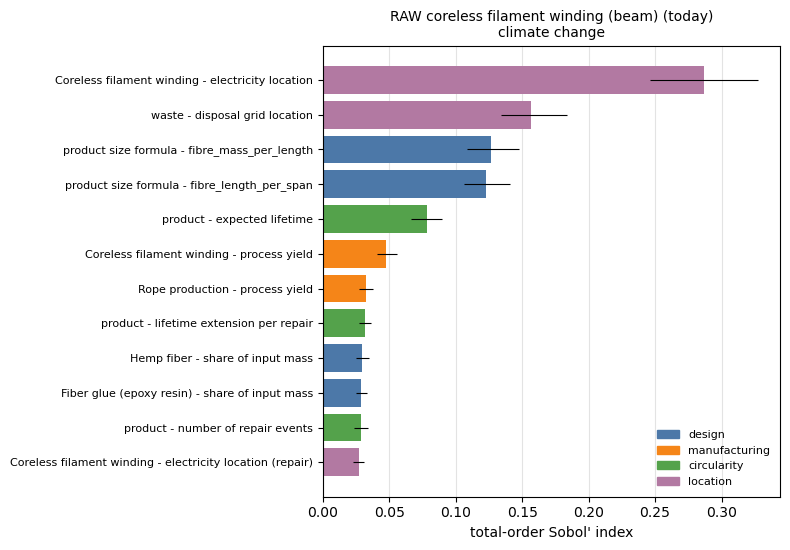

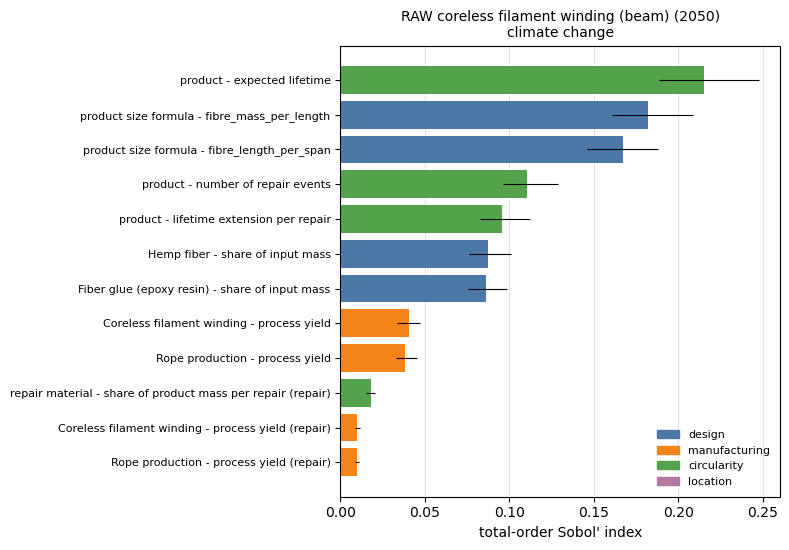

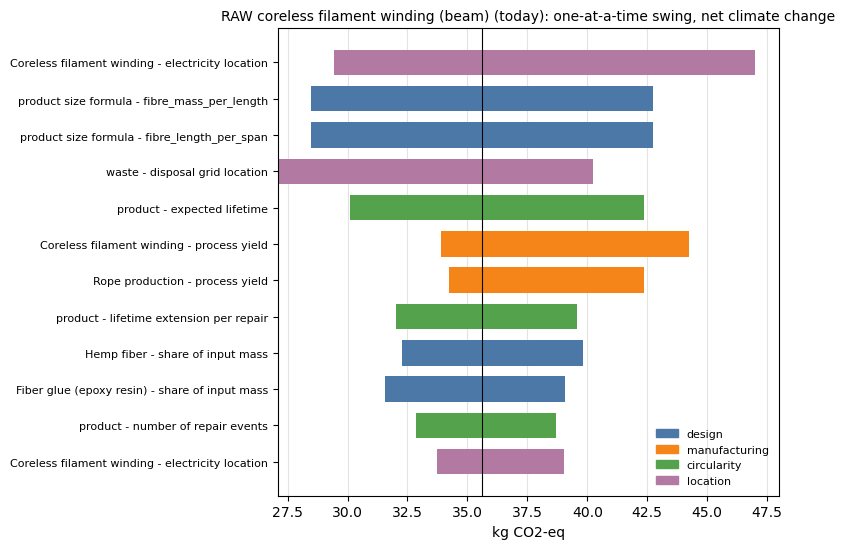

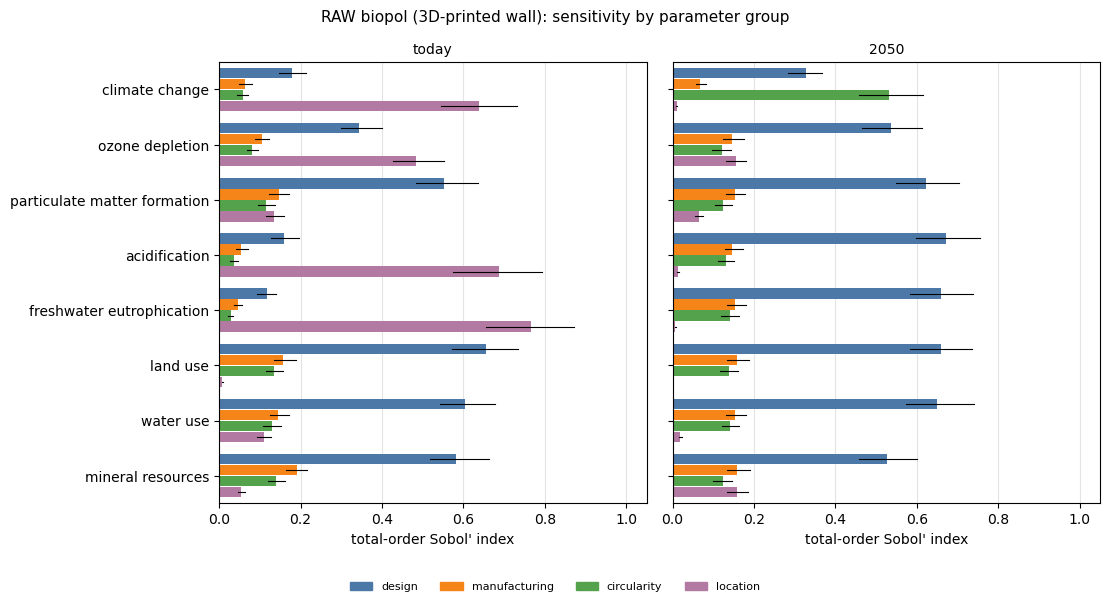

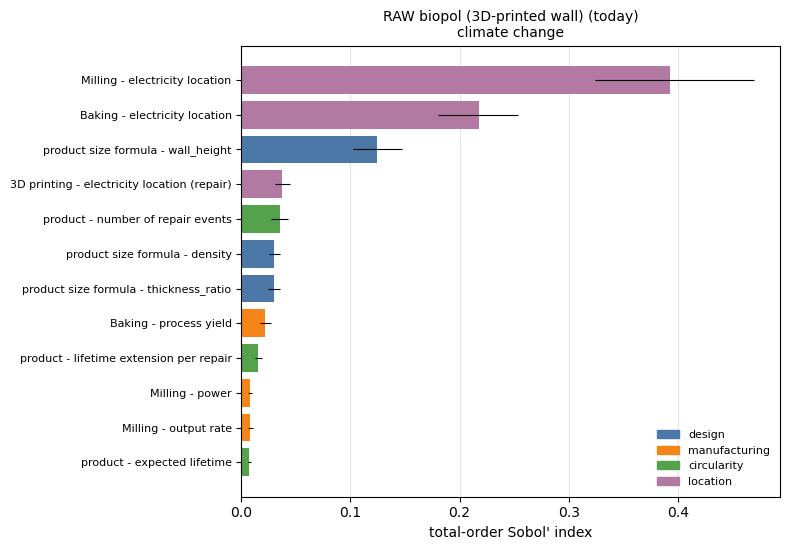

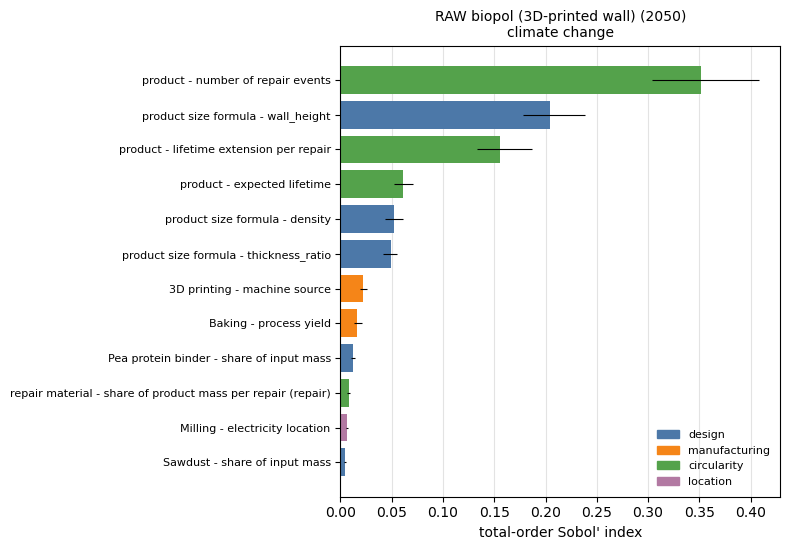

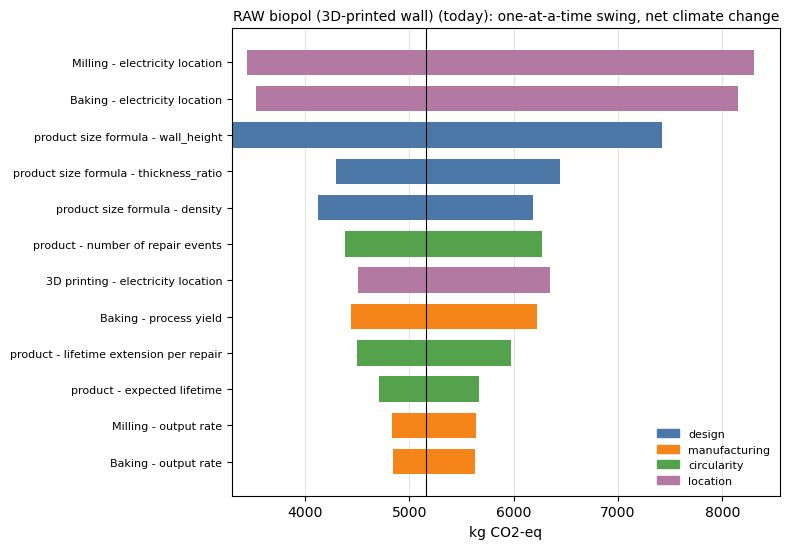

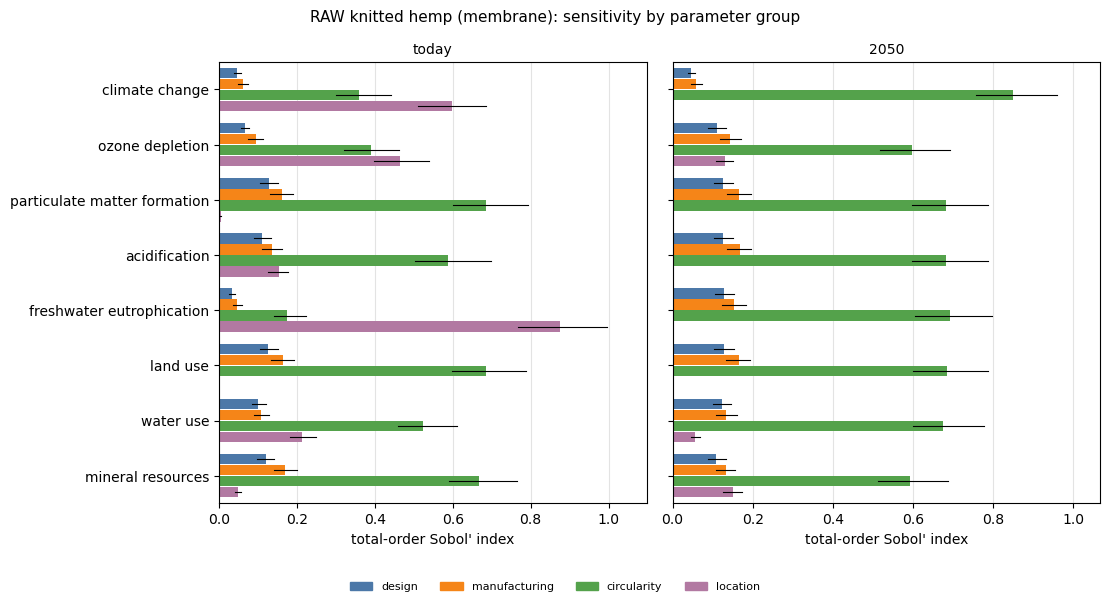

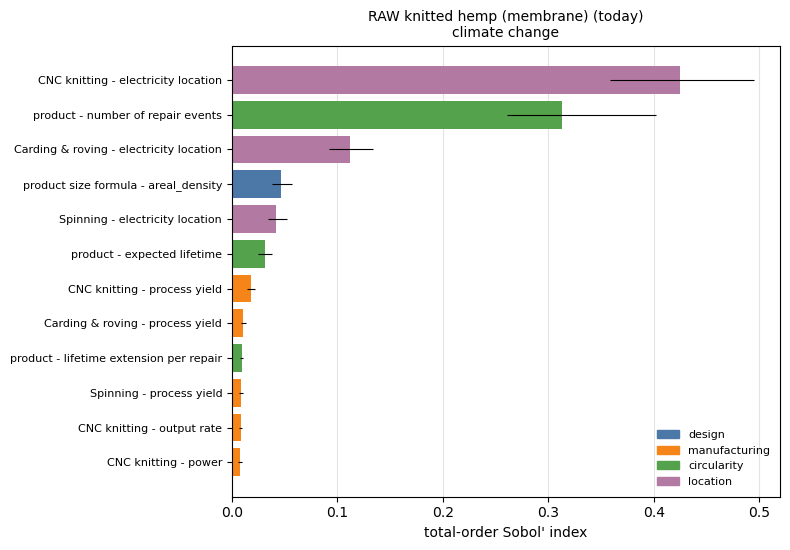

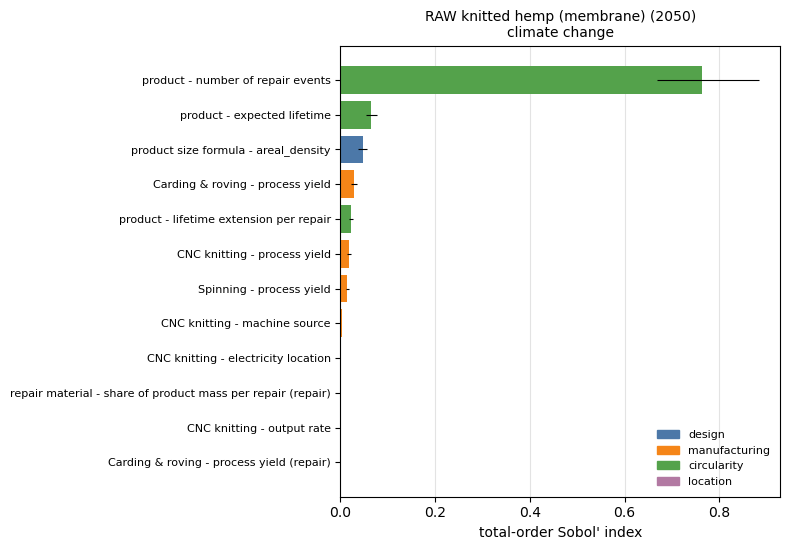

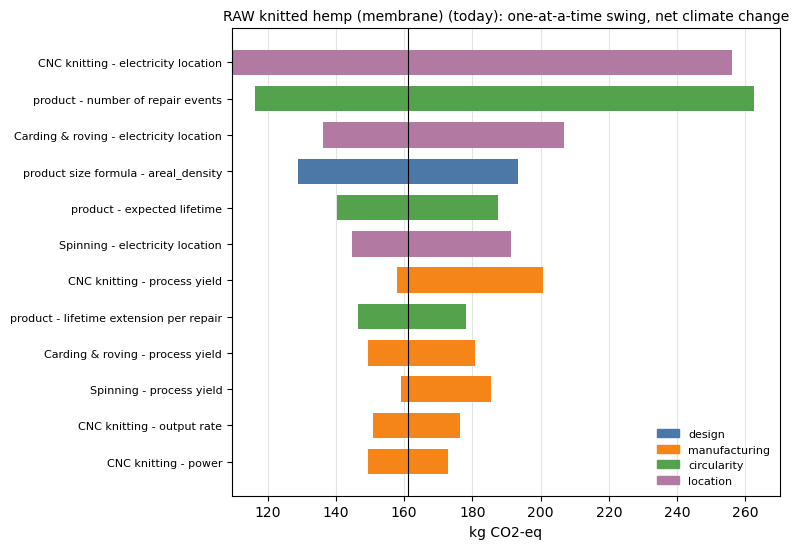

In [2]:
all_group = {}          # group-level Sobol' indices per case and background, used by the summary table below
for case_id, display_name in inp.raw_cases().items():
    by_group, by_param = {}, {}
    all_group[case_id] = by_group
    for sid, lab in ((id_a, label_a), (id_b, label_b)):
        by_group[lab] = sobol(models[sid], case_id, N, seed, by="group")
        by_param[lab] = sobol(models[sid], case_id, N, seed, by="parameter")
        by_group[lab].assign(raw_case=case_id, background=lab).to_csv(RESULTS / "tables" / f"sobol_group_{case_id}_{sid}.csv", index=False)
        by_param[lab].assign(raw_case=case_id, background=lab).to_csv(RESULTS / "tables" / f"sobol_parameter_{case_id}_{sid}.csv", index=False)
    fig = plot_group_sensitivity(inp, f"{display_name}: sensitivity by parameter group", by_group)
    fig.savefig(RESULTS / "figures" / f"sensitivity_groups_{case_id}.png", dpi=150); fig.savefig(RESULTS / "figures" / f"sensitivity_groups_{case_id}.pdf")
    plt.show()
    for lab in (label_a, label_b):
        fig = plot_parameter_sensitivity(f"{display_name} ({lab})", by_param[lab], "climate change")
        fig.savefig(RESULTS / "figures" / f"sensitivity_parameters_{case_id}_{lab.replace(' ', '')}.png", dpi=150)
        plt.show()
    tor = tornado(models[id_a], case_id, "climate change")
    tor.to_csv(RESULTS / "tables" / f"tornado_{case_id}.csv", index=False)
    fig = plot_tornado(f"{display_name} ({label_a}): one-at-a-time swing, net climate change", tor, "kg CO2-eq")
    fig.savefig(RESULTS / "figures" / f"tornado_{case_id}.png", dpi=150)
    plt.show()

## Summary: which parameter type matters most?

For every impact category (row) and RAW case (column): the parameter group with the largest **total-order Sobol' index** (share of the variance of the net impact that the group explains, including its interactions with the other groups) - design, manufacturing, circularity or location. One table per background. A trailing * marks a close call: the 95 % interval of the top group overlaps that of the runner-up. Colours are the same as in the sensitivity charts.

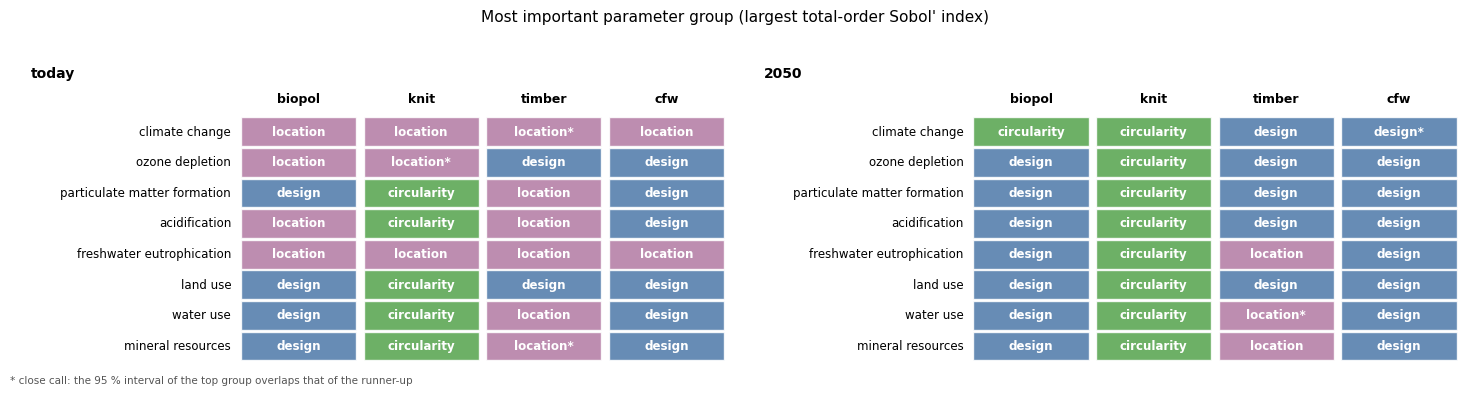

In [3]:
from raw_lca.summary import top_group_table

CASE_ORDER = ["raw_biopol", "raw_knit", "raw_timber", "raw_cfw"]     # column order of the table (presentation only)
tables_top = {lab: top_group_table(inp, {c: all_group[c][lab] for c in CASE_ORDER}, CASE_ORDER) for lab in (label_a, label_b)}
for lab, t in tables_top.items():
    t.to_csv(RESULTS / "tables" / f"top_parameter_group_{lab.replace(' ', '')}.csv")
fig = plot_top_group_tables(tables_top, "Most important parameter group (largest total-order Sobol' index)")
fig.savefig(RESULTS / "figures" / "summary_top_group.png", dpi=150); fig.savefig(RESULTS / "figures" / "summary_top_group.pdf")
plt.show()

## Range of the net impact when one parameter group is varied

Two charts per RAW case, one for today and one for 2050. In each chart, every charted impact category has four horizontal box plots, one per parameter group. In each box plot only the parameters of that group are varied by Monte Carlo (from the distributions on the sheet: typical, min, max; locations drawn uniformly from `location_choices`); all other parameters stay at their typical values. Box: 25-75 %, whiskers: the interval percentiles set on the sheet (`interval_percentiles`), line: median, dotted line: net impact at typical values. Number of draws per group: `mc_iterations`. Background (ecoinvent) uncertainty is not included.

**Axis: % of the largest net impact of the category in that chart** (100 % = the largest absolute value among the whisker ends and the typical-value result of the four groups; the absolute value is written next to the category name; negative values are net benefits). Each category is scaled separately, so all categories share one axis, like the bar charts. Because today and 2050 are separate charts with separate scales, compare their absolute values through the numbers next to the category names, not through the bar positions.

**How this relates to the Sobol' indices.** The box plots show the *size* of the spread (what a partner would see if only that group of choices changed); the Sobol' indices show the *share of the total variance* each group explains, including interactions, and are comparable across categories and cases. The two agree on the ranking in most cases, but need not match exactly: the box plots keep the other groups at typical values (no interactions), so widths do not add up, the box and whiskers ignore rare extreme values that dominate a variance, and the total-order index also counts what a group does in combination with the others.

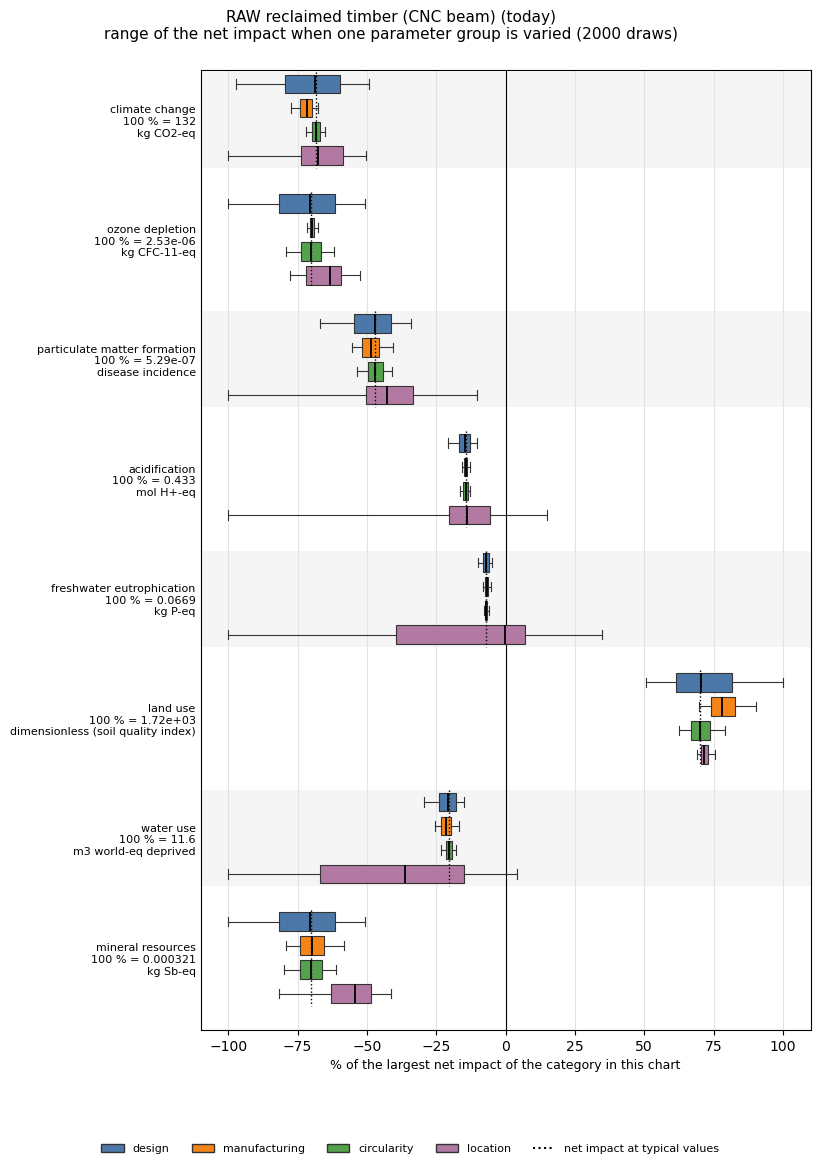

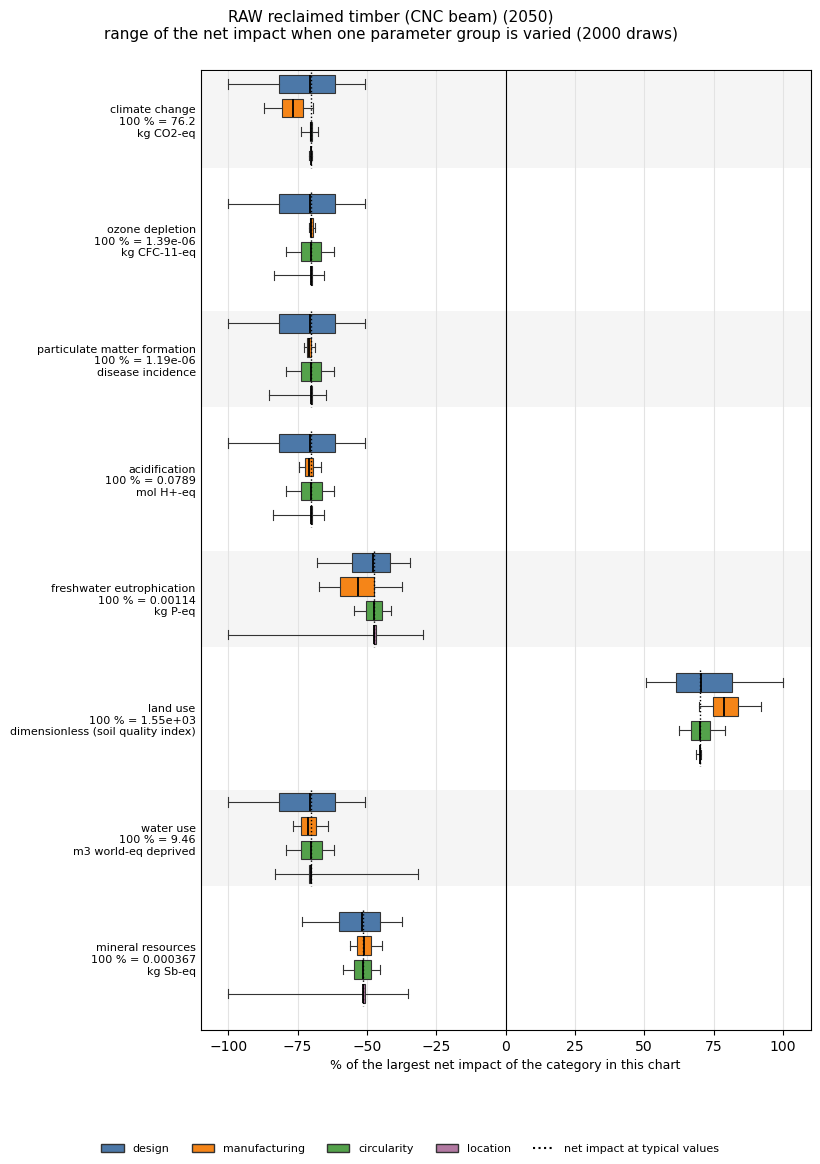

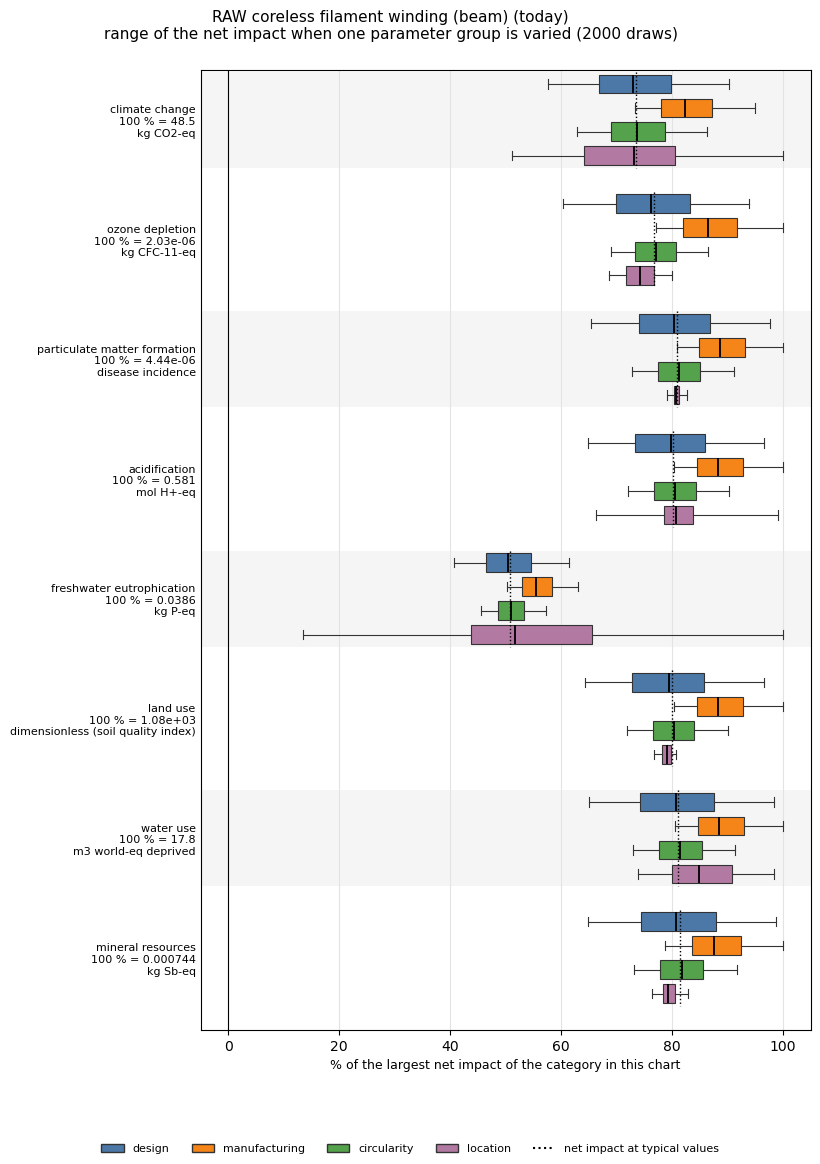

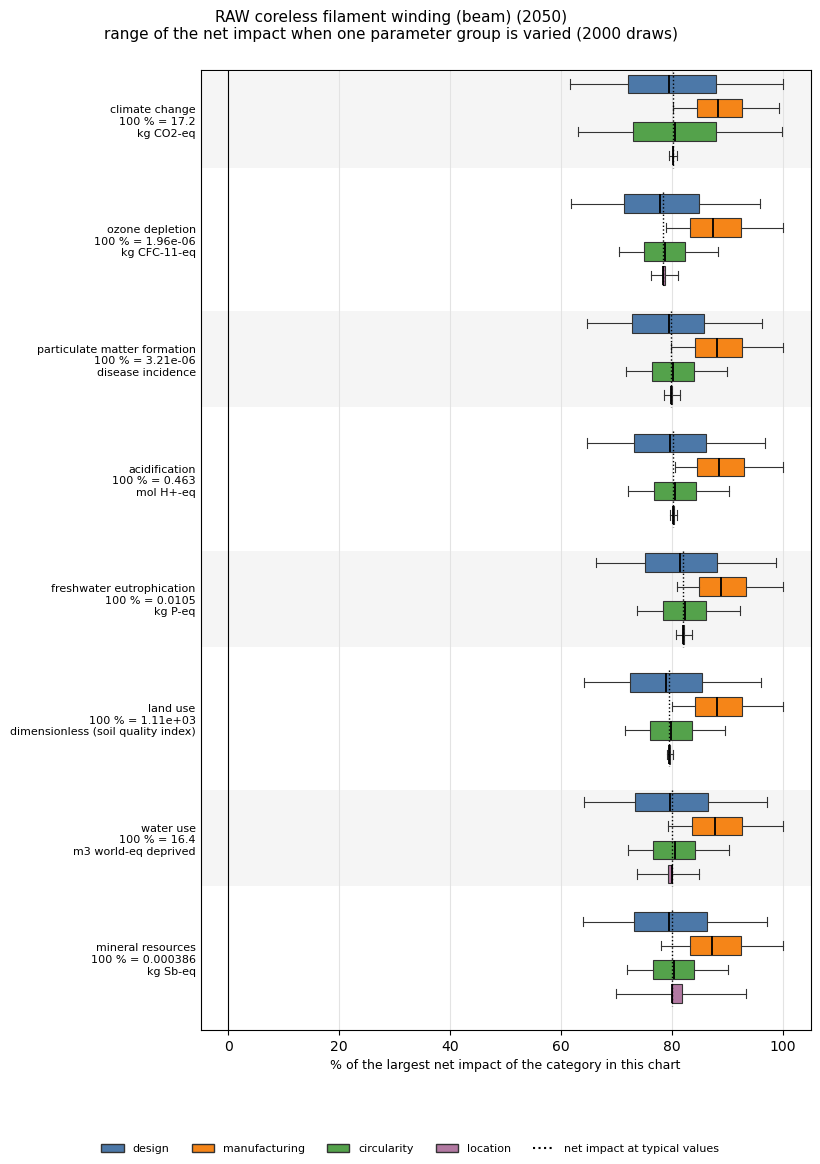

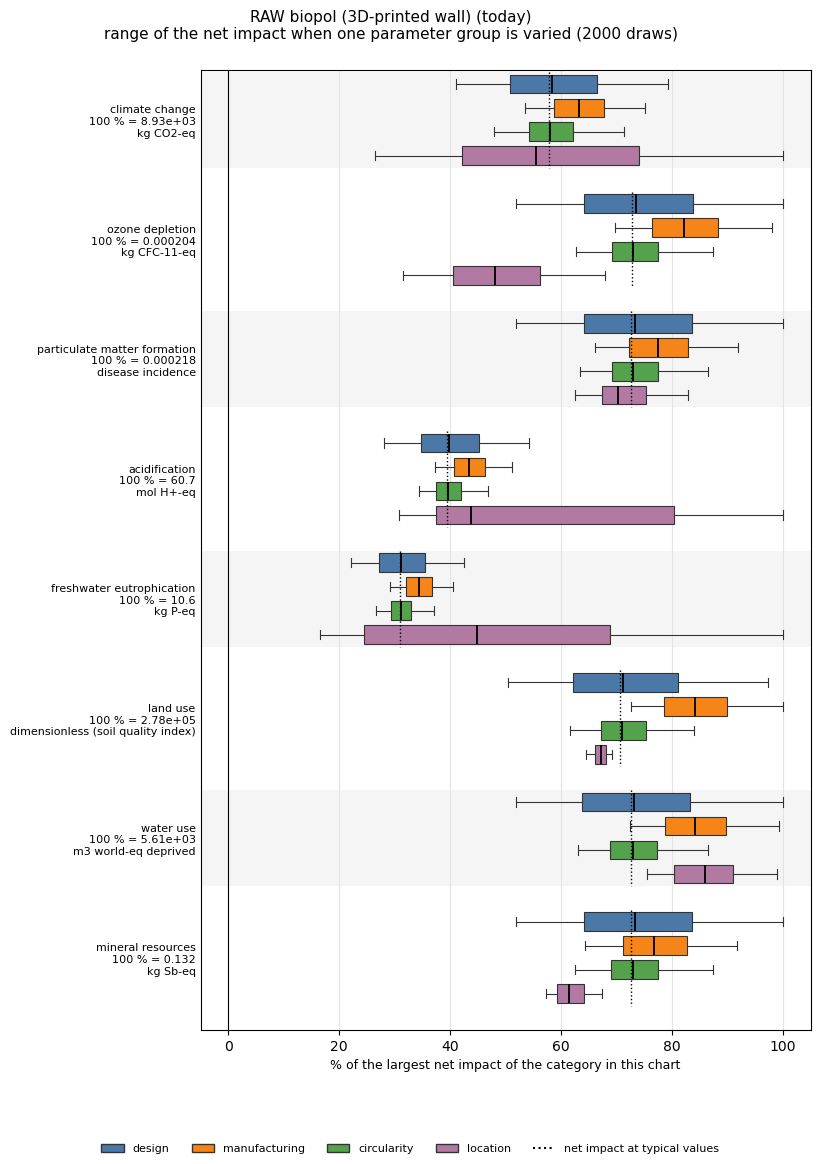

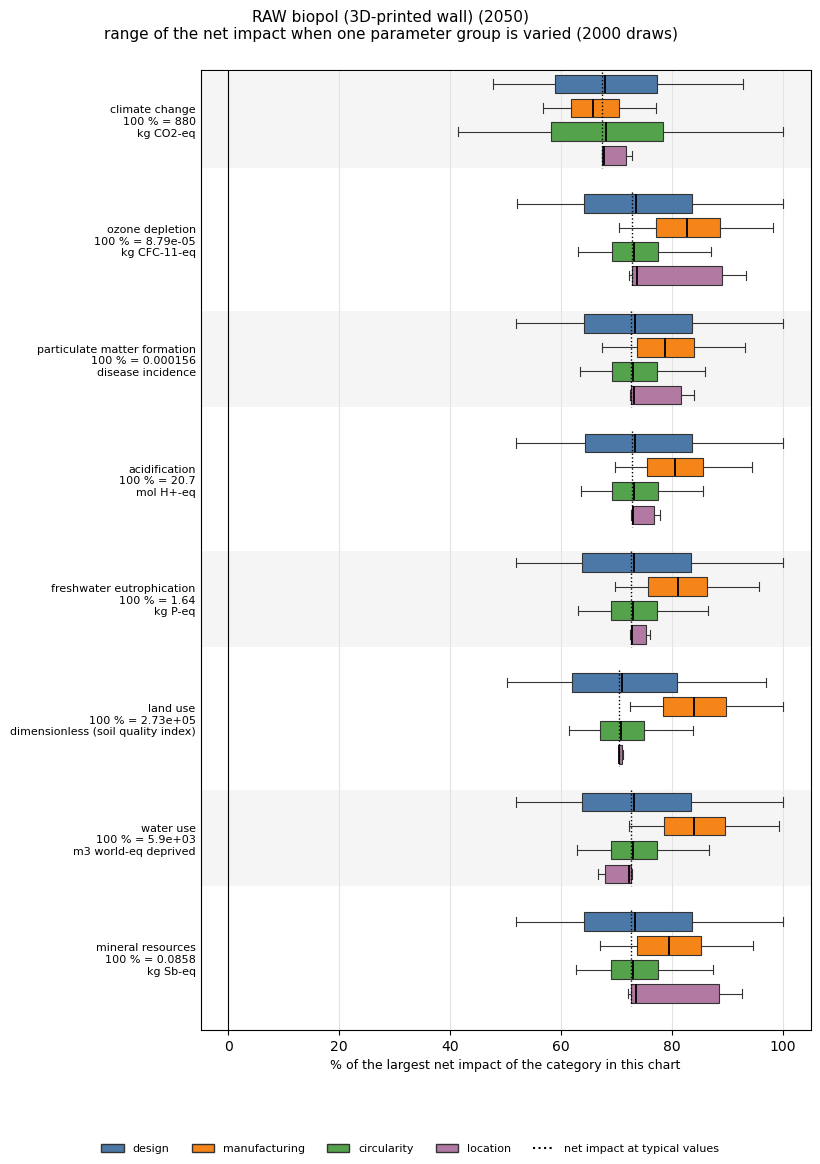

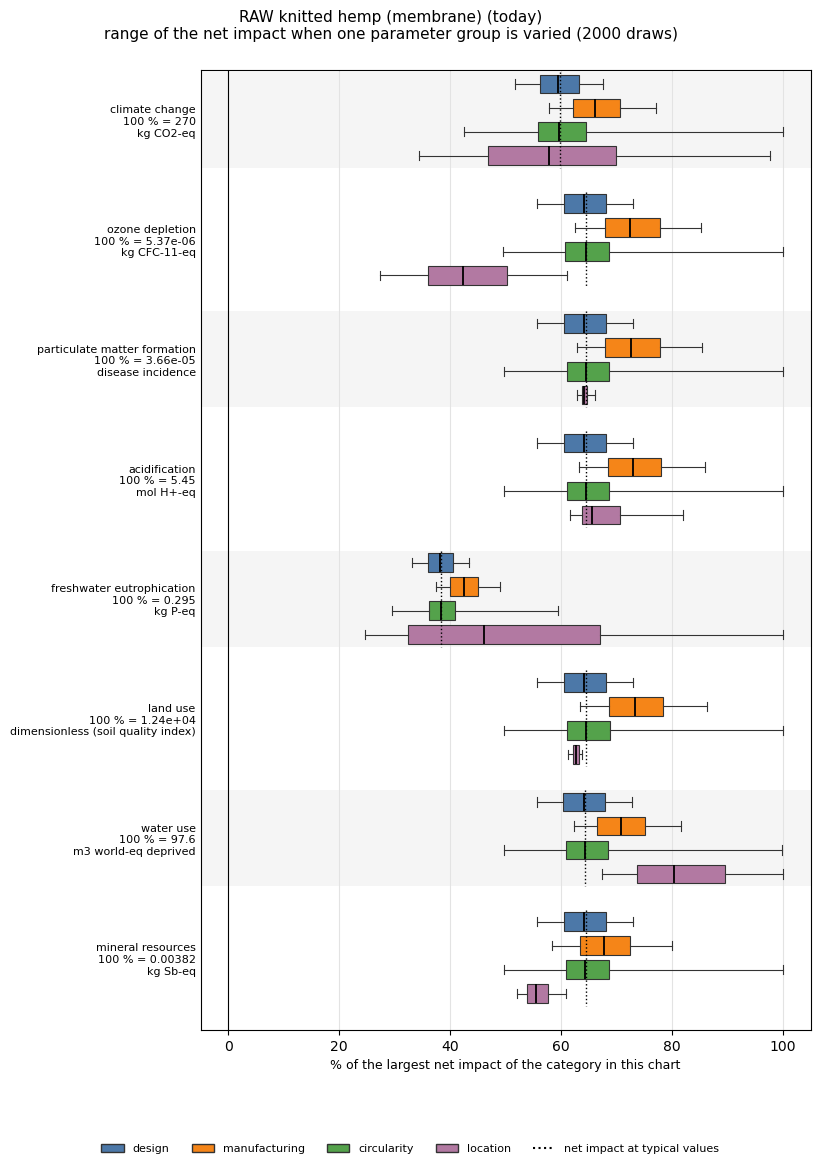

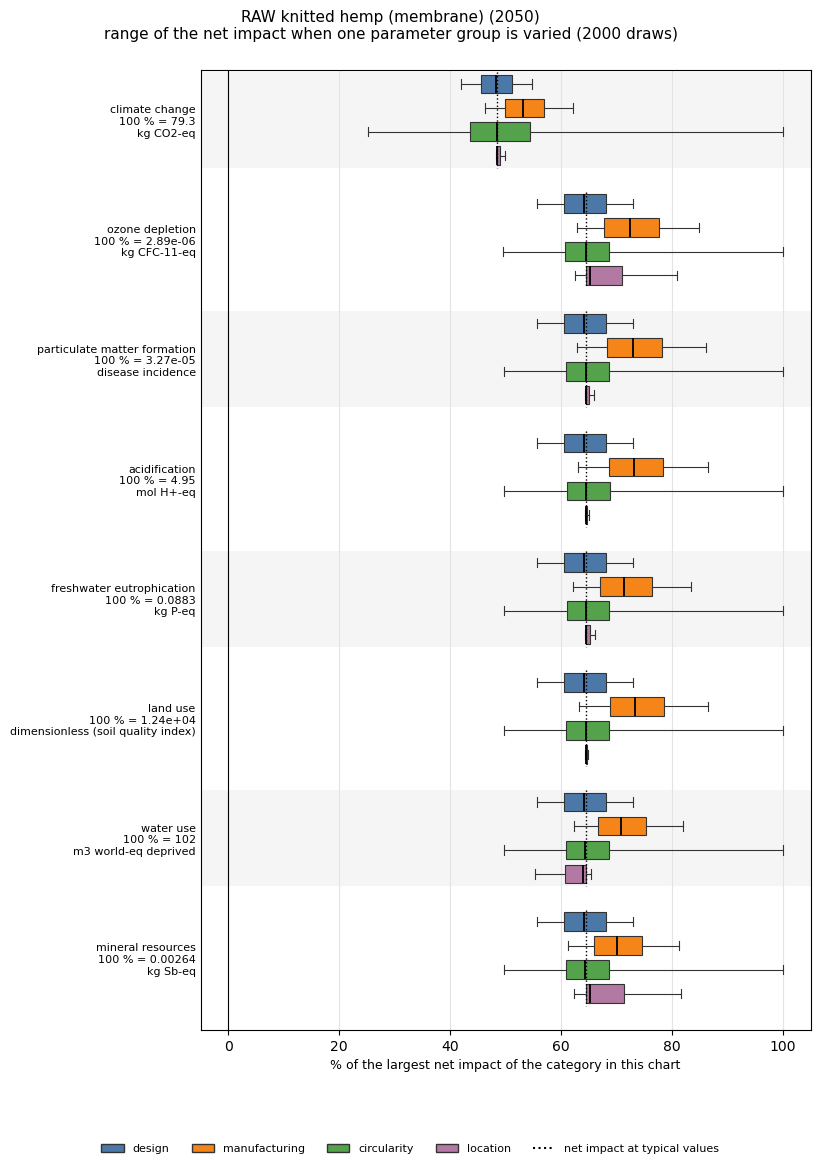

In [4]:
from raw_lca.sensitivity import group_samples
from raw_lca.study import run_raw_only
from raw_lca.plots import plot_group_boxplots

n_draws = int(inp.setup["mc_iterations"])
whis = tuple(float(p) for p in str(inp.setup["interval_percentiles"]).split(";"))
for case_id, display_name in inp.raw_cases().items():
    for sid, lab in ((id_a, label_a), (id_b, label_b)):
        samples = group_samples(models[sid], case_id, n_draws, seed)
        typical = run_raw_only(models[sid], case_id).net
        fig = plot_group_boxplots(inp, f"{display_name} ({lab})\nrange of the net impact when one parameter group is varied ({n_draws} draws)",
                                  samples, typical, whis, models[sid].bg.categories, models[sid].bg.units)
        fig.savefig(RESULTS / "figures" / f"boxplots_groups_{case_id}_{lab.replace(' ', '')}.png", dpi=150)
        fig.savefig(RESULTS / "figures" / f"boxplots_groups_{case_id}_{lab.replace(' ', '')}.pdf")
        plt.show()